In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Predicting Wind Direction with Recurrent Neural Networks

# Load data

In [9]:
dfwind_train = pd.read_csv('https://github.com/fonsecamig/agrn_course/blob/422e4f90b210c99f5fed2ae93a26cdeb5ef4feae/data/wd_train.csv?raw=true')
dfwind_val = pd.read_csv('https://github.com/fonsecamig/agrn_course/blob/422e4f90b210c99f5fed2ae93a26cdeb5ef4feae/data/wd_val.csv?raw=true')
dfwind_test = pd.read_csv('https://github.com/fonsecamig/agrn_course/blob/422e4f90b210c99f5fed2ae93a26cdeb5ef4feae/data/wd_test.csv?raw=true')

In [11]:
dfwind_train['wind direction'] = pd.Categorical(dfwind_train['wind direction'])
dfwind_val['wind direction'] = pd.Categorical(dfwind_val['wind direction'])
dfwind_test['wind direction'] = pd.Categorical(dfwind_test['wind direction'])

In [12]:
dfwind_train

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wind direction
0,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,S
1,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,S
2,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,S
3,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,E
4,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,994.41,0.44,274.04,-0.06,96.4,6.31,6.08,0.23,3.81,6.11,1263.19,1.47,2.36,S
59996,994.53,0.61,274.19,-0.10,95.0,6.38,6.06,0.32,3.80,6.10,1262.61,0.50,0.72,E
59997,994.62,2.02,275.61,1.12,93.7,7.07,6.63,0.45,4.15,6.66,1255.94,0.22,0.54,O
59998,995.04,2.27,275.82,0.75,89.6,7.20,6.45,0.75,4.04,6.48,1255.43,0.75,1.02,S


<Axes: >

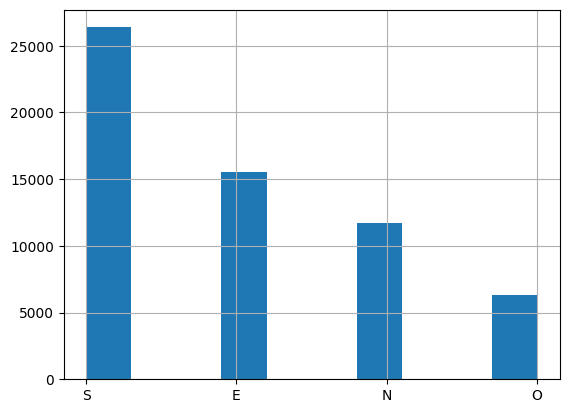

In [13]:
dfwind_train['wind direction'].hist()

## Exercise 1:

Using the above datasets (train, validation and test), train a recurrent neural network to predict the wind direction for each of the next 6 hours using all the weather data from the last 3 days(72 hours).